In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
df = sns.load_dataset("titanic")


In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.shape

(891, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(107)

In [ ]:
df = df.drop_duplicates()
df.drop(columns=['embark_town','class','alive','deck'], inplace= True, errors = 'ignore')

In [10]:
median = df["age"].median()
df["age"] = df["age"].fillna(median)
print (df ["age"].isnull().sum())

0


In [11]:
mode = df["embarked"].mode()[0]
df["embarked"] = df["embarked"].fillna(mode)
print (df ["embarked"].isnull().sum())

0


In [12]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
who           0
adult_male    0
alone         0
dtype: int64

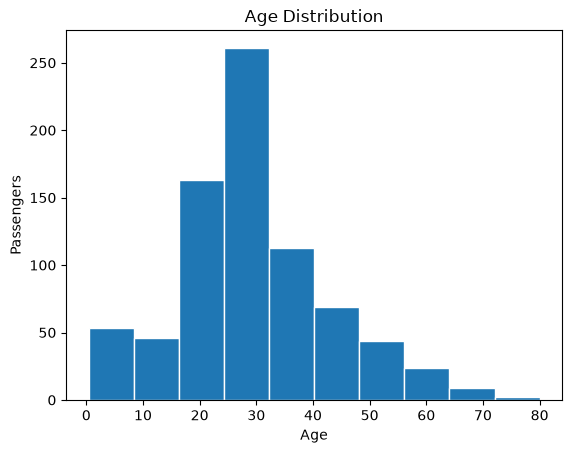

In [13]:
plt.hist(df["age"], edgecolor = 'white')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passengers")
plt.show()

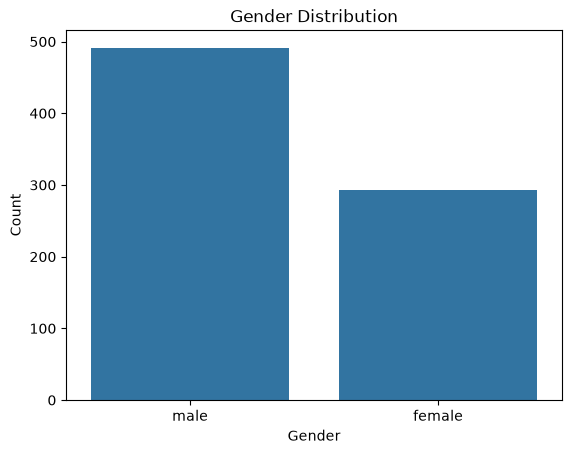

In [14]:
sns.countplot(x="sex", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

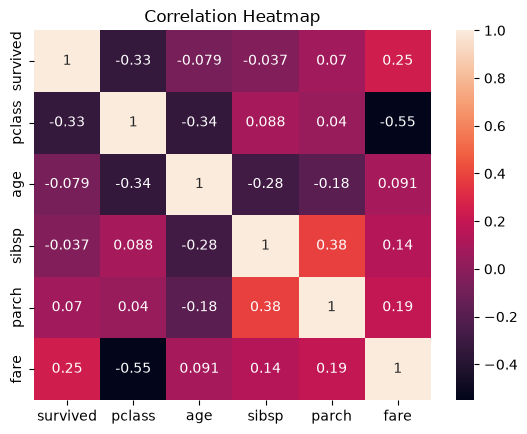

In [15]:
sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True)

plt.title("Correlation Heatmap")

plt.show()

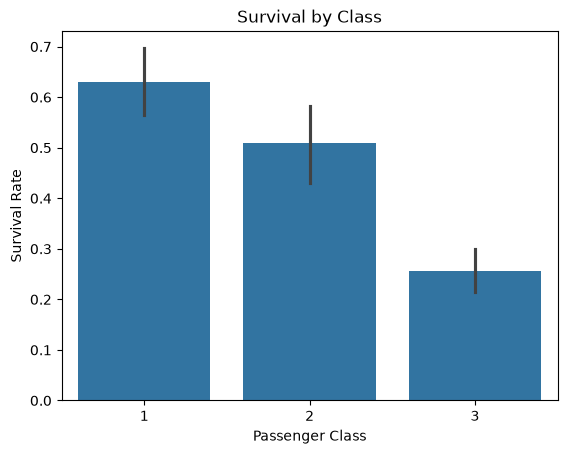

In [16]:
sns.barplot(x="pclass",
            y="survived",
            data=df)

plt.title("Survival by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

In [17]:
df["family_size"] = (
    df["sibsp"] +
    df["parch"] + 1
)



In [18]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,man,True,False,2
1,1,1,female,38.0,1,0,71.2833,C,woman,False,False,2
2,1,3,female,26.0,0,0,7.9250,S,woman,False,True,1
3,1,1,female,35.0,1,0,53.1000,S,woman,False,False,2
4,0,3,male,35.0,0,0,8.0500,S,man,True,True,1


In [19]:
df["is_alone"] = (
    df["family_size"] == 1
).astype(int)


In [20]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,False,2,0
1,1,1,female,38.0,1,0,71.2833,C,woman,False,False,2,0
2,1,3,female,26.0,0,0,7.9250,S,woman,False,True,1,1
3,1,1,female,35.0,1,0,53.1000,S,woman,False,False,2,0
4,0,3,male,35.0,0,0,8.0500,S,man,True,True,1,1


In [21]:
df["fare_per_person"] = (
    df["fare"] /
    df["family_size"]
)


In [22]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone,family_size,is_alone,fare_per_person
0,0,3,male,22.0,1,0,7.2500,S,man,True,False,2,0,3.62500
1,1,1,female,38.0,1,0,71.2833,C,woman,False,False,2,0,35.64165
2,1,3,female,26.0,0,0,7.9250,S,woman,False,True,1,1,7.92500
3,1,1,female,35.0,1,0,53.1000,S,woman,False,False,2,0,26.55000
4,0,3,male,35.0,0,0,8.0500,S,man,True,True,1,1,8.05000


In [23]:
# Save cleaned dataset
df.to_csv("titanic_clean.csv", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   survived         784 non-null    int64  
 1   pclass           784 non-null    int64  
 2   sex              784 non-null    str    
 3   age              784 non-null    float64
 4   sibsp            784 non-null    int64  
 5   parch            784 non-null    int64  
 6   fare             784 non-null    float64
 7   embarked         784 non-null    str    
 8   who              784 non-null    str    
 9   adult_male       784 non-null    bool   
 10  alone            784 non-null    bool   
 11  family_size      784 non-null    int64  
 12  is_alone         784 non-null    int64  
 13  fare_per_person  784 non-null    float64
dtypes: bool(2), float64(3), int64(6), str(3)
memory usage: 81.2 KB


In [25]:
df['parch'].value_counts()

parch
0    580
1    114
2     75
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [26]:
df['sibsp'].value_counts()

sibsp
0    517
1    201
2     27
4     18
3     14
5      5
8      2
Name: count, dtype: int64

In [31]:
df = pd.get_dummies(df, columns=['sex'], dtype=int)

KeyError: "None of [Index(['sex'], dtype='str')] are in the [columns]"

In [30]:
df.head()

,survived,pclass,age,sibsp,parch,fare,embarked,who,adult_male,alone,family_size,is_alone,fare_per_person,sex_female,sex_male
0,0,3,22.0,1,0,7.2500,S,man,True,False,2,0,3.62500,False,True
1,1,1,38.0,1,0,71.2833,C,woman,False,False,2,0,35.64165,True,False
2,1,3,26.0,0,0,7.9250,S,woman,False,True,1,1,7.92500,True,False
3,1,1,35.0,1,0,53.1000,S,woman,False,False,2,0,26.55000,True,False
4,0,3,35.0,0,0,8.0500,S,man,True,True,1,1,8.05000,False,True
